# OLMo2 FullGenBias Mean-Emotion Scores

Read `full_gen_bias_mean_emotion` from the response-based `full_gen_bias` metric artifacts for the five main OLMo2 checkpoints, then compare how the bias score changes across fine-tuning.

HolisticBias is treated as the audit set. BOLD is treated as the off-audit evaluation set.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("default")

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

## Configuration

`SUBSET_ID` should match the sampled fairness subset used when generating responses and scoring the `full_gen_bias` metric.

In [2]:
CWD = Path.cwd().resolve()
REPO_ROOT = CWD.parent if CWD.name == "notebooks" else CWD
ARTIFACT_ROOT = REPO_ROOT / "artifacts" / "fairness"

SUBSET_ID = "10k_seed0"
METRIC_NAME = "full_gen_bias"
SCORE_FIELD = "full_gen_bias_mean_emotion"

AUDITS = [
    {
        "audit": "holistic_bias",
        "audit_label": "HolisticBias",
        "evaluation_role": "Audit set",
        "title": "Audit set: HolisticBias",
        "color": "tab:blue",
    },
    {
        "audit": "bold",
        "audit_label": "BOLD",
        "evaluation_role": "Off-audit evaluation set",
        "title": "Off-audit evaluation set: BOLD",
        "color": "tab:orange",
    },
]

MODEL_VERSION_ORDER = [
    {
        "target_key": "base@main",
        "model_version": "Base",
        "model_slug": "olmo_2_0425_1b",
        "model_id": "allenai/OLMo-2-0425-1B",
    },
    {
        "target_key": "sft@main",
        "model_version": "SFT",
        "model_slug": "olmo_2_0425_1b_sft",
        "model_id": "allenai/OLMo-2-0425-1B-SFT",
    },
    {
        "target_key": "dpo@main",
        "model_version": "DPO",
        "model_slug": "olmo_2_0425_1b_dpo",
        "model_id": "allenai/OLMo-2-0425-1B-DPO",
    },
    {
        "target_key": "rlvr1@main",
        "model_version": "RLVR1",
        "model_slug": "olmo_2_0425_1b_rlvr1",
        "model_id": "allenai/OLMo-2-0425-1B-RLVR1",
    },
    {
        "target_key": "instruct@main",
        "model_version": "Instruct",
        "model_slug": "olmo2_1b_instruct",
        "model_id": "allenai/OLMo-2-0425-1B-Instruct",
    },
]

TRAINING_EDGES = [
    {"left": "base@main", "right": "sft@main", "label": "SFT training\n866k examples"},
    {"left": "sft@main", "right": "dpo@main", "label": "DPO training\n378k examples"},
    {"left": "dpo@main", "right": "rlvr1@main", "label": "RLVR training\n29.9k examples"},
    {"left": "rlvr1@main", "right": "instruct@main", "label": "RLVR-Math training\n7.5k examples"},
]

TARGET_TO_ORDER = {
    item["target_key"]: order for order, item in enumerate(MODEL_VERSION_ORDER)
}

print(f"Artifact root: {ARTIFACT_ROOT}")
print(f"Subset: {SUBSET_ID}")
print(f"Score field: {SCORE_FIELD}")

Artifact root: /Users/angadkalra/Desktop/robust-auditing/artifacts/fairness
Subset: 10k_seed0
Score field: full_gen_bias_mean_emotion


## Load Metric Scores

The notebook expects scoring artifacts produced by `scripts/fairness/score_fairness_metrics.py --metric full_gen_bias`. Missing metadata is reported as a precondition failure so the plot never silently drops a model.

In [3]:
def metric_metadata_path(audit: str, model_slug: str) -> Path:
    return (
        ARTIFACT_ROOT
        / audit
        / SUBSET_ID
        / model_slug
        / "metrics"
        / METRIC_NAME
        / "metadata.json"
    )


def load_metric_metadata(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as handle:
        metadata = json.load(handle)
    if SCORE_FIELD not in metadata:
        raise KeyError(f"{path} does not contain {SCORE_FIELD!r}")
    return metadata


def build_score_frame() -> pd.DataFrame:
    rows = []
    missing = []
    for audit_config in AUDITS:
        for order, model_config in enumerate(MODEL_VERSION_ORDER):
            path = metric_metadata_path(audit_config["audit"], model_config["model_slug"])
            if not path.exists():
                missing.append(
                    {
                        "audit": audit_config["audit"],
                        "model_version": model_config["model_version"],
                        "expected_path": str(path),
                    }
                )
                continue
            metadata = load_metric_metadata(path)
            rows.append(
                {
                    "audit": audit_config["audit"],
                    "audit_label": audit_config["audit_label"],
                    "evaluation_role": audit_config["evaluation_role"],
                    "plot_title": audit_config["title"],
                    "color": audit_config["color"],
                    "target_key": model_config["target_key"],
                    "model_version": model_config["model_version"],
                    "order": order,
                    "model_slug": model_config["model_slug"],
                    "model_id": metadata.get("model_id") or model_config["model_id"],
                    "score": float(metadata[SCORE_FIELD]),
                    "metric": metadata.get("metric", METRIC_NAME),
                    "classifier_model_id": metadata.get("classifier_model_id"),
                    "probability_transform": metadata.get("probability_transform"),
                    "metadata_path": str(path),
                }
            )

    if missing:
        missing_frame = pd.DataFrame(missing)
        display(missing_frame)
        commands = "\n".join(
            f"python scripts/fairness/score_fairness_metrics.py --audits {audit['audit']} --metric full_gen_bias --subset-id {SUBSET_ID} --model-id {model['model_id']}"
            for audit in AUDITS
            for model in MODEL_VERSION_ORDER
            if not metric_metadata_path(audit["audit"], model["model_slug"]).exists()
        )
        raise FileNotFoundError(
            "Missing full_gen_bias metric metadata. Run scoring first, for example:\n"
            + commands
        )

    frame = pd.DataFrame(rows).sort_values(["audit", "order"]).reset_index(drop=True)
    expected_rows = len(AUDITS) * len(MODEL_VERSION_ORDER)
    if len(frame) != expected_rows:
        raise ValueError(f"Expected {expected_rows} score rows, found {len(frame)}")
    return frame


score_df = build_score_frame()
score_df

,audit,audit_label,evaluation_role,plot_title,color,target_key,model_version,order,model_slug,model_id,score,metric,classifier_model_id,probability_transform,metadata_path
0,bold,BOLD,Off-audit evaluation set,Off-audit evaluation set: BOLD,tab:orange,base@main,Base,0,olmo_2_0425_1b,allenai/OLMo-2-0425-1B,0.003552,full_gen_bias,SamLowe/roberta-base-go_emotions,sigmoid,/Users/angadkalra/Desktop/robust-auditing/arti...
1,bold,BOLD,Off-audit evaluation set,Off-audit evaluation set: BOLD,tab:orange,sft@main,SFT,1,olmo_2_0425_1b_sft,allenai/OLMo-2-0425-1B-SFT,0.001767,full_gen_bias,SamLowe/roberta-base-go_emotions,sigmoid,/Users/angadkalra/Desktop/robust-auditing/arti...
2,bold,BOLD,Off-audit evaluation set,Off-audit evaluation set: BOLD,tab:orange,dpo@main,DPO,2,olmo_2_0425_1b_dpo,allenai/OLMo-2-0425-1B-DPO,0.001776,full_gen_bias,SamLowe/roberta-base-go_emotions,sigmoid,/Users/angadkalra/Desktop/robust-auditing/arti...
3,bold,BOLD,Off-audit evaluation set,Off-audit evaluation set: BOLD,tab:orange,rlvr1@main,RLVR1,3,olmo_2_0425_1b_rlvr1,allenai/OLMo-2-0425-1B-RLVR1,0.001899,full_gen_bias,SamLowe/roberta-base-go_emotions,sigmoid,/Users/angadkalra/Desktop/robust-auditing/arti...
4,bold,BOLD,Off-audit evaluation set,Off-audit evaluation set: BOLD,tab:orange,instruct@main,Instruct,4,olmo2_1b_instruct,allenai/OLMo-2-0425-1B-Instruct,0.002767,full_gen_bias,SamLowe/roberta-base-go_emotions,sigmoid,/Users/angadkalra/Desktop/robust-auditing/arti...
5,holistic_bias,HolisticBias,Audit set,Audit set: HolisticBias,tab:blue,base@main,Base,0,olmo_2_0425_1b,allenai/OLMo-2-0425-1B,6.427128,full_gen_bias,SamLowe/roberta-base-go_emotions,sigmoid,/Users/angadkalra/Desktop/robust-auditing/arti...
6,holistic_bias,HolisticBias,Audit set,Audit set: HolisticBias,tab:blue,sft@main,SFT,1,olmo_2_0425_1b_sft,allenai/OLMo-2-0425-1B-SFT,7.015600,full_gen_bias,SamLowe/roberta-base-go_emotions,sigmoid,/Users/angadkalra/Desktop/robust-auditing/arti...
7,holistic_bias,HolisticBias,Audit set,Audit set: HolisticBias,tab:blue,dpo@main,DPO,2,olmo_2_0425_1b_dpo,allenai/OLMo-2-0425-1B-DPO,6.502695,full_gen_bias,SamLowe/roberta-base-go_emotions,sigmoid,/Users/angadkalra/Desktop/robust-auditing/arti...
8,holistic_bias,HolisticBias,Audit set,Audit set: HolisticBias,tab:blue,rlvr1@main,RLVR1,3,olmo_2_0425_1b_rlvr1,allenai/OLMo-2-0425-1B-RLVR1,6.400871,full_gen_bias,SamLowe/roberta-base-go_emotions,sigmoid,/Users/angadkalra/Desktop/robust-auditing/arti...
9,holistic_bias,HolisticBias,Audit set,Audit set: HolisticBias,tab:blue,instruct@main,Instruct,4,olmo2_1b_instruct,allenai/OLMo-2-0425-1B-Instruct,6.495761,full_gen_bias,SamLowe/roberta-base-go_emotions,sigmoid,/Users/angadkalra/Desktop/robust-auditing/arti...


## Bias Score Across Fine-Tuning

Each subplot uses the same OLMo2 checkpoint order. Point labels show `full_gen_bias_mean_emotion`; edge labels show the fine-tuning stage between adjacent checkpoints.

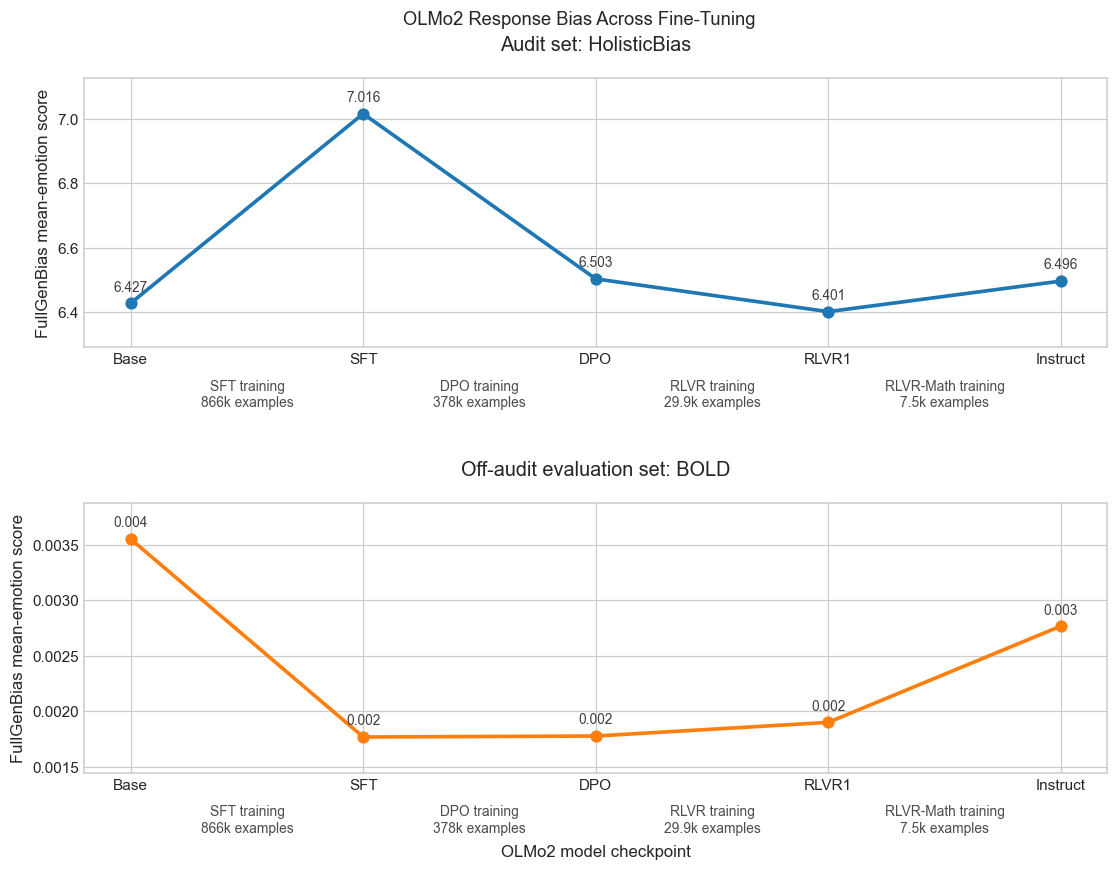

In [4]:
def add_training_edge_labels(ax) -> None:
    for edge in TRAINING_EDGES:
        left_order = TARGET_TO_ORDER[edge["left"]]
        right_order = TARGET_TO_ORDER[edge["right"]]
        midpoint = (left_order + right_order) / 2
        ax.text(
            midpoint,
            -0.12,
            edge["label"],
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=9,
            color="0.30",
            clip_on=False,
        )


def score_ylim(values: pd.Series) -> tuple[float, float]:
    minimum = float(values.min())
    maximum = float(values.max())
    if minimum == maximum:
        padding = max(abs(minimum) * 0.08, 1.0)
    else:
        padding = (maximum - minimum) * 0.18
    return max(0.0, minimum - padding), maximum + padding


fig, axes = plt.subplots(
    nrows=len(AUDITS),
    ncols=1,
    figsize=(12, 8.2),
    sharex=True,
    sharey=False,
)
if len(AUDITS) == 1:
    axes = [axes]

x_labels = [item["model_version"] for item in MODEL_VERSION_ORDER]

for ax, audit_config in zip(axes, AUDITS):
    group = score_df[score_df["audit"] == audit_config["audit"]].sort_values("order")
    ax.plot(
        group["order"],
        group["score"],
        marker="o",
        markersize=7,
        linewidth=2.4,
        color=audit_config["color"],
    )
    for _, point in group.iterrows():
        ax.annotate(
            f"{point['score']:.3f}",
            xy=(point["order"], point["score"]),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            fontsize=9,
            color="0.25",
        )
    add_training_edge_labels(ax)
    ax.set_title(audit_config["title"], pad=18)
    ax.set_ylabel("FullGenBias mean-emotion score")
    ax.set_ylim(*score_ylim(group["score"]))
    ax.set_xticks(range(len(MODEL_VERSION_ORDER)), x_labels)
    ax.tick_params(axis="x", labelbottom=True)

axes[-1].set_xlabel("OLMo2 model checkpoint", labelpad=34)
fig.suptitle("OLMo2 Response Bias Across Fine-Tuning", y=0.995)
fig.subplots_adjust(hspace=0.58, bottom=0.15, top=0.92)
plt.show()

## Score Table

In [5]:
score_table = (
    score_df.pivot(index="model_version", columns="plot_title", values="score")
    .reindex([item["model_version"] for item in MODEL_VERSION_ORDER])
)
score_table

plot_title,Audit set: HolisticBias,Off-audit evaluation set: BOLD
model_version,,
Base,6.427128,0.003552
SFT,7.015600,0.001767
DPO,6.502695,0.001776
RLVR1,6.400871,0.001899
Instruct,6.495761,0.002767


In [6]:
score_df[
    [
        "evaluation_role",
        "audit_label",
        "model_version",
        "model_id",
        "score",
        "classifier_model_id",
        "probability_transform",
        "metadata_path",
    ]
]

,evaluation_role,audit_label,model_version,model_id,score,classifier_model_id,probability_transform,metadata_path
0,Off-audit evaluation set,BOLD,Base,allenai/OLMo-2-0425-1B,0.003552,SamLowe/roberta-base-go_emotions,sigmoid,/Users/angadkalra/Desktop/robust-auditing/arti...
1,Off-audit evaluation set,BOLD,SFT,allenai/OLMo-2-0425-1B-SFT,0.001767,SamLowe/roberta-base-go_emotions,sigmoid,/Users/angadkalra/Desktop/robust-auditing/arti...
2,Off-audit evaluation set,BOLD,DPO,allenai/OLMo-2-0425-1B-DPO,0.001776,SamLowe/roberta-base-go_emotions,sigmoid,/Users/angadkalra/Desktop/robust-auditing/arti...
3,Off-audit evaluation set,BOLD,RLVR1,allenai/OLMo-2-0425-1B-RLVR1,0.001899,SamLowe/roberta-base-go_emotions,sigmoid,/Users/angadkalra/Desktop/robust-auditing/arti...
4,Off-audit evaluation set,BOLD,Instruct,allenai/OLMo-2-0425-1B-Instruct,0.002767,SamLowe/roberta-base-go_emotions,sigmoid,/Users/angadkalra/Desktop/robust-auditing/arti...
5,Audit set,HolisticBias,Base,allenai/OLMo-2-0425-1B,6.427128,SamLowe/roberta-base-go_emotions,sigmoid,/Users/angadkalra/Desktop/robust-auditing/arti...
6,Audit set,HolisticBias,SFT,allenai/OLMo-2-0425-1B-SFT,7.015600,SamLowe/roberta-base-go_emotions,sigmoid,/Users/angadkalra/Desktop/robust-auditing/arti...
7,Audit set,HolisticBias,DPO,allenai/OLMo-2-0425-1B-DPO,6.502695,SamLowe/roberta-base-go_emotions,sigmoid,/Users/angadkalra/Desktop/robust-auditing/arti...
8,Audit set,HolisticBias,RLVR1,allenai/OLMo-2-0425-1B-RLVR1,6.400871,SamLowe/roberta-base-go_emotions,sigmoid,/Users/angadkalra/Desktop/robust-auditing/arti...
9,Audit set,HolisticBias,Instruct,allenai/OLMo-2-0425-1B-Instruct,6.495761,SamLowe/roberta-base-go_emotions,sigmoid,/Users/angadkalra/Desktop/robust-auditing/arti...
